In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "data/dogs"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("TensorFlow version:", tf.__version__)
print("Dataset path:", DATA_DIR)

TensorFlow version: 2.20.0
Dataset path: data/dogs


In [3]:
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Number of classes: 120
First 10 classes: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound']


2026-02-07 12:57:29.653785: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


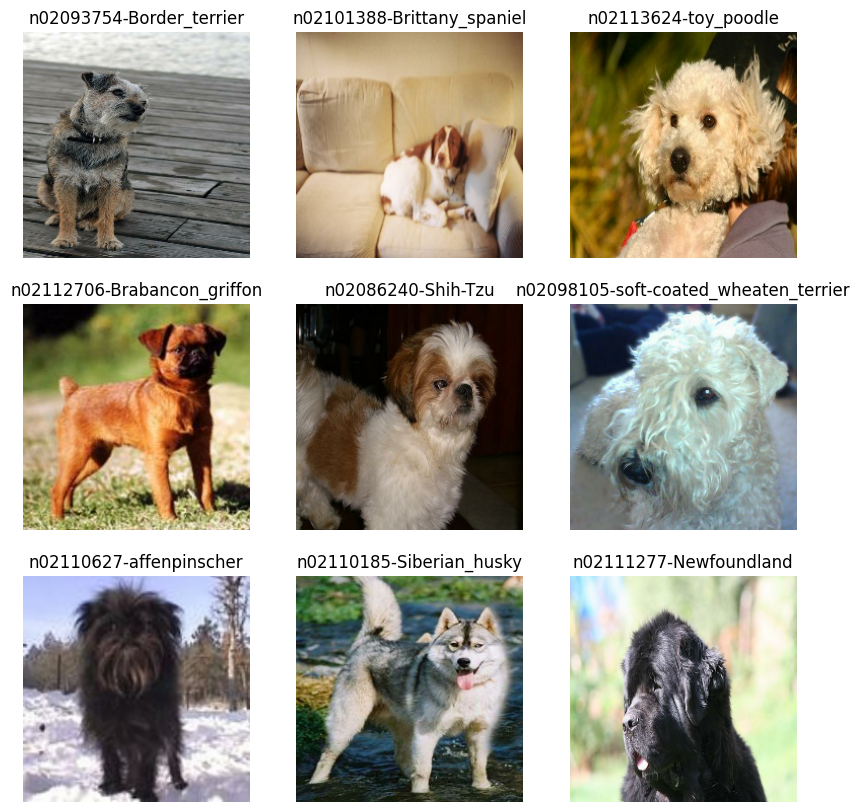

In [4]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

preprocess_input = tf.keras.applications.efficientnet.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [6]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False
inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 132s 251ms/step - accuracy: 0.5041 - loss: 1.9773 - val_accuracy: 0.8149 - val_loss: 0.6168
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 348s 677ms/step - accuracy: 0.6618 - loss: 1.2156 - val_accuracy: 0.8163 - val_loss: 0.6027
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 316s 614ms/step - accuracy: 0.7029 - loss: 1.0409 - val_accuracy: 0.8207 - val_loss: 0.5911
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 155s 301ms/step - accuracy: 0.7159 - loss: 0.9653 - val_accuracy: 0.8275 - val_loss: 0.5654
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 128s 248ms/step - accuracy: 0.7269 - loss: 0.9128 - val_accuracy: 0.8309 - val_loss: 0.5848


In [8]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.9)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

FINE_TUNE_EPOCHS = 2

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS
)

Epoch 1/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 159s 303ms/step - accuracy: 0.5691 - loss: 1.5635 - val_accuracy: 0.7665 - val_loss: 0.8072
Epoch 2/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 145s 282ms/step - accuracy: 0.5811 - loss: 1.4985 - val_accuracy: 0.7677 - val_loss: 0.7922


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


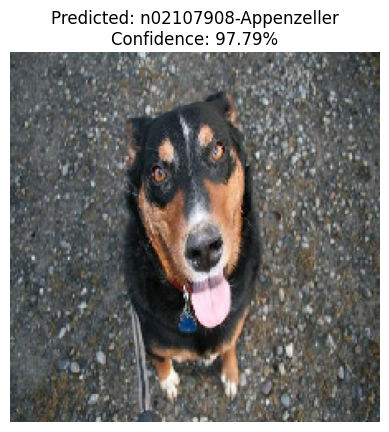

Actual class: n02107908-Appenzeller
Predicted class: n02107908-Appenzeller
Confidence: 97.79%


In [13]:
random_class = random.choice(class_names)
class_dir = os.path.join(DATA_DIR, random_class)

random_image = random.choice(os.listdir(class_dir))
image_path = os.path.join(class_dir, random_image)

img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  

img_array = preprocess_input(img_array)

predictions = model.predict(img_array)
predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index]

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}",
    fontsize=12
)
plt.show()

print("Actual class:", random_class)
print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence:.2%}")

In [12]:
model.save("dog_breed_model.keras")
print("Model saved.")

Model saved.


In [14]:
import os
import json
import tensorflow as tf

EXPORT_DIR = "exported_model"
MODEL_DIR = os.path.join(EXPORT_DIR, "dog_breed_classifier")

os.makedirs(EXPORT_DIR, exist_ok=True)
model.export(MODEL_DIR)

with open(os.path.join(EXPORT_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f)

model_metadata = {
    "img_size": IMG_SIZE,
    "num_classes": num_classes,
    "preprocessing": "tf.keras.applications.efficientnet.preprocess_input",
    "architecture": "EfficientNetB0 (transfer learning)"
}

with open(os.path.join(EXPORT_DIR, "model_metadata.json"), "w") as f:
    json.dump(model_metadata, f)

print("Saved Model path:", MODEL_DIR)

INFO:tensorflow:Assets written to: exported_model/dog_breed_classifier/assets


INFO:tensorflow:Assets written to: exported_model/dog_breed_classifier/assets


Saved artifact at 'exported_model/dog_breed_classifier'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 120), dtype=tf.float32, name=None)
Captures:
  4774756176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4774748304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4774748112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4779698960: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  4779698384: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  4771848336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4774742352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4771848144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4771842192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4771848528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4773850832: TensorSpe